# BASE CLUSTER MODELLING

For the clusterning based on the issues type, 
* Centroid based clustering - KMeans
* Hierarchical based clustering - HAC



In [8]:
# Import the necessary modules
import numpy as np
import scipy.sparse as sp
import sys
import os 
import pandas as pd 
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt 
import seaborn as sns
from pathlib import Path
import pickle

In [9]:
def find_root():
    cwd = Path.cwd()
    core_name = "EMATM0067_2025_TB-2-g43"
    
    for path in [cwd] + list(cwd.parents):
        if path.name.startswith(core_name):
            return path
            
    for path in cwd.rglob(f"{core_name}*"):
        if path.is_dir():
            return path
            
    return cwd

root_path = find_root()

# Convert to absolute path for reliability
root_path = root_path.resolve()

if str(root_path) not in sys.path:
    sys.path.insert(0, str(root_path))

# Switch to the project root
os.chdir(root_path)

reports_dir = root_path / 'reports'
figures_dir = reports_dir / 'figures'
tables_dir = reports_dir / 'tables'

# Create folders if they don't exist
figures_dir.mkdir(parents=True, exist_ok=True)
tables_dir.mkdir(parents=True, exist_ok=True)

data_file = root_path / 'data' / 'raw' / 'customer_support_tickets.csv'

if data_file.exists():
    print("PROJECT INITIALIZATION SUCCESSFUL")
    print(f"Project Root: {root_path}")
    print(f"Data Source: {data_file}")
    print(f"Figures will be saved to:\n {figures_dir}")
    print(f"Tables will be saved to:\n {tables_dir}")
else:
    print(f"ERROR: Data file not found at:\n {data_file}")
    print("Please ensure the 'data/raw' folder exists inside the project directory.")

PROJECT INITIALIZATION SUCCESSFUL
Project Root: E:\Study\Bristol\IATA\Group_Project\Code\EMATM0067_2025_TB-2-g43-ThiruvelAP
Data Source: E:\Study\Bristol\IATA\Group_Project\Code\EMATM0067_2025_TB-2-g43-ThiruvelAP\data\raw\customer_support_tickets.csv
Figures will be saved to:
 E:\Study\Bristol\IATA\Group_Project\Code\EMATM0067_2025_TB-2-g43-ThiruvelAP\reports\figures
Tables will be saved to:
 E:\Study\Bristol\IATA\Group_Project\Code\EMATM0067_2025_TB-2-g43-ThiruvelAP\reports\tables


In [10]:
from src.evaluation.ClusterEvaluation import evaluate_clusters
from src.clustering.KMeans import run_kmeans
from src.clustering.Hac import run_hac
from src.features.Embeddings import bow_vectorizer, vectorize_boa, tfidf_vectorizer, vectorize_tfidf
from src.evaluation.Cluster_Interpretability import plot_cluster_top_words, plot_cluster_heatmaps, plot_cluster_size
from src.evaluation.Cluster_Stability import visualize_cluster_stability

In [11]:
# Define the data directory relative to the root
data_dir = os.path.join(root_path, 'data', 'processed')
source_data_dir = os.path.join(root_path, 'data', 'raw')
file_name = 'customer_support_tickets.csv' 
file_path = os.path.join(source_data_dir, file_name)

# load the dataframe
df = pd.read_csv(file_path)
print(df.head())

# 1. Bag of Words
bow_path = os.path.join(data_dir, 'bow_vectors.npz')
X_bow = sp.load_npz(bow_path)

# 2. TF-IDF
tfidf_path = os.path.join(data_dir, 'tfidf_vectors.npz')
X_tfidf = sp.load_npz(tfidf_path)

# 3. Skipgram
skipgram_path = os.path.join(data_dir, 'skipgram_embeddings.npy')
X_skipgram = np.load(skipgram_path)

# 4. SBERT
sbert_path = os.path.join(data_dir, 'sbert_embeddings.npy')
X_sbert = np.load(sbert_path)

print(f"Successfully loaded BoW from: {bow_path}")
print(f"Successfully loaded TF-IDF from: {tfidf_path}")
print(f"Successfully loaded Skipgram from: {skipgram_path}")
print(f"Successfully loaded SBERT from: {sbert_path}")

   Ticket ID        Customer Name              Customer Email  Customer Age  \
0          1        Marisa Obrien  carrollallison@example.com            32   
1          2         Jessica Rios    clarkeashley@example.com            42   
2          3  Christopher Robbins   gonzalestracy@example.com            48   
3          4     Christina Dillon    bradleyolson@example.org            27   
4          5    Alexander Carroll     bradleymark@example.com            67   

  Customer Gender Product Purchased Date of Purchase      Ticket Type  \
0           Other        GoPro Hero       2021-03-22  Technical issue   
1          Female       LG Smart TV       2021-05-22  Technical issue   
2           Other          Dell XPS       2020-07-14  Technical issue   
3          Female  Microsoft Office       2020-11-13  Billing inquiry   
4          Female  Autodesk AutoCAD       2020-02-04  Billing inquiry   

             Ticket Subject  \
0             Product setup   
1  Peripheral compatibil

In [12]:
# Clustering sweep 
def run_clustering_sweep(X, y_type, y_subj, name, metric='cosine', k_range=range(2, 11)):
    results = []
    for k in k_range:
        # KMeans 
        km_labels = run_kmeans(X = X, k = k)
        # Kmeans scores on ticket type 
        km_sil, km_ari_type, km_nmi_type = evaluate_clusters(
            X = X, 
            cluster_labels = km_labels, 
            true_labels = y_type, 
            metric=metric
        )
        # Kmeans scores on ticket type 
        km_sil, km_ari_subj, km_nmi_subj = evaluate_clusters(
            X = X, 
            cluster_labels = km_labels, 
            true_labels = y_subj, 
            metric=metric
        )
        # Append the current k label and scores  
        results.append({'Representation': name, 'Algorithm': 'KMeans', 'k': k,
            'Silhouette': km_sil, 'ARI (Type)': km_ari_type, 'NMI (Type)': km_nmi_type,
            'ARI (Subject)': km_ari_subj, 'NMI (Subject)': km_nmi_subj})
        # HAC
        hac_labels = run_hac(X = X, k = k)
        # HAC scores on ticket type
        hac_sil, hac_ari_type, hac_nmi_type = evaluate_clusters(
            X = X, 
            cluster_labels = hac_labels, 
            true_labels = y_type,
            metric=metric
        )
        # HAC scores on ticket type 
        hac_sil, hac_ari_subj, hac_nmi_subj = evaluate_clusters(
            X = X, 
            cluster_labels = hac_labels, 
            true_labels = y_subj,
            metric=metric
        )
        # Append the current k label and scores
        results.append({'Representation': name, 'Algorithm': 'HAC', 'k': k,
            'Silhouette': hac_sil, 'ARI (Type)': hac_ari_type, 'NMI (Type)': hac_nmi_type,
            'ARI (Subject)': hac_ari_subj, 'NMI (Subject)': hac_nmi_subj})
    return pd.DataFrame(results)

In [13]:
# Encode the ticket type and ticket subject
le = LabelEncoder()
y_type = le.fit_transform(df['Ticket Type'])
y_subj = le.fit_transform(df['Ticket Subject'])

In [14]:
df_tfidf = run_clustering_sweep(X_tfidf, y_type, y_subj, 'TF-IDF', metric='cosine')
df_sbert = run_clustering_sweep(X_sbert, y_type, y_subj, 'SBERT', metric='cosine')
df_bow = run_clustering_sweep(X_bow, y_type, y_subj, 'BoW', metric='cosine')
df_skip = run_clustering_sweep(X_skipgram, y_type, y_subj, 'Skipgram', metric='cosine')

# Final results
all_results = pd.concat([df_tfidf, df_sbert, df_bow, df_skip], ignore_index=True)

In [15]:
all_results.head()

,Representation,Algorithm,k,Silhouette,ARI (Type),NMI (Type),ARI (Subject),NMI (Subject)
0,TF-IDF,KMeans,2,0.034795,-0.000068,0.000457,-0.000059,0.000525
1,TF-IDF,HAC,2,0.031754,-0.000044,0.000418,-0.000005,0.000455
2,TF-IDF,KMeans,3,0.043846,-0.000201,0.000593,0.000021,0.000919
3,TF-IDF,HAC,3,0.034167,-0.000138,0.000636,-0.000026,0.000893
4,TF-IDF,KMeans,4,0.062029,-0.000061,0.000661,-0.000013,0.001214


Saved figure: clusterninganalysis_cluster.png


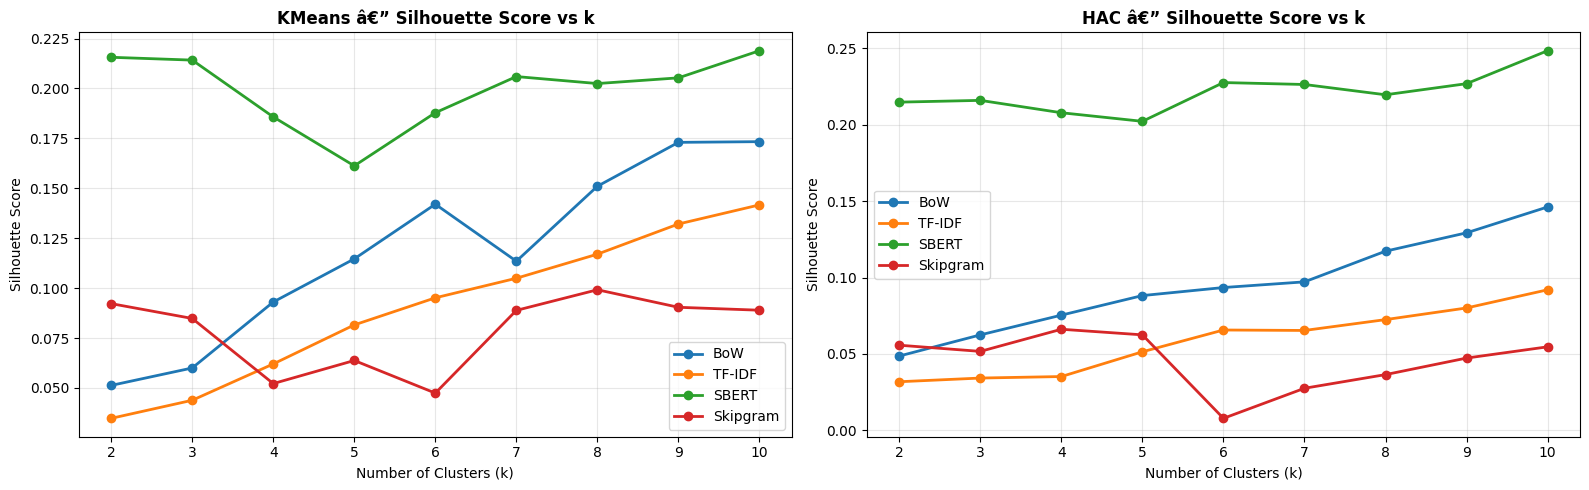

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for ax, algo in zip(axes, ['KMeans', 'HAC']):
    subset = all_results[all_results['Algorithm'] == algo]
    for rep in ['BoW', 'TF-IDF', 'SBERT', 'Skipgram']:
        rep_data = subset[subset['Representation'] == rep]
        ax.plot(rep_data['k'], rep_data['Silhouette'], marker='o', label=rep, linewidth=2)
    ax.set_title(f'{algo} â€” Silhouette Score vs k', fontsize=12, fontweight='bold')
    ax.set_xlabel('Number of Clusters (k)')
    ax.set_ylabel('Silhouette Score')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_xticks(range(2, 11))
plt.tight_layout()
plt.savefig(os.path.join(figures_dir, 'clustering_silhouette_scores.png'), dpi=300, bbox_inches='tight')

# Save figure
if not os.path.exists(figures_dir):
    os.makedirs(figures_dir, exist_ok=True)
plt.savefig(os.path.join(figures_dir, 'clusterninganalysis_cluster.png'), dpi=300, bbox_inches='tight')
print(f"Saved figure: clusterninganalysis_cluster.png")

plt.show()

## CLUSTER INTERPERTABILITY

#### Cluster Interpertability for the KMean on Ticket Issues 
 - The number of clusters, k = 5, was selected based on the number of ticket issues, which makes it a natural hypothesis to assume the number of clusters and a direct mapping of ticket issues with the clusters. 
- While silhouette scores do not show a sharp elbow at k=5, the balanced class distribution across ticket types further supports this selection, as KMeans performs optimally with similarly sized clusters.

In [17]:
# KM for BoW
km_bow_labels = run_kmeans(X = X_bow.toarray(), k = 5)

# KM for TFIDF
km_tfidf_labels = run_kmeans(X = X_tfidf.toarray(), k = 5)

# KM for Skipgram
km_skipgram_labels = run_kmeans(X = X_skipgram, k = 5)

# KM for sbert 
km_sbert_labels = run_kmeans(X = X_sbert, k = 5)

#### BoW and TF-IDF top 10 selected words

In [18]:
# cleaned text 
cleaned_text_df = pd.read_csv(os.path.join(root_path, "data/processed/cleaned_text/cleaned_text.csv"))

len(cleaned_text_df["cleaned_description"])

8469

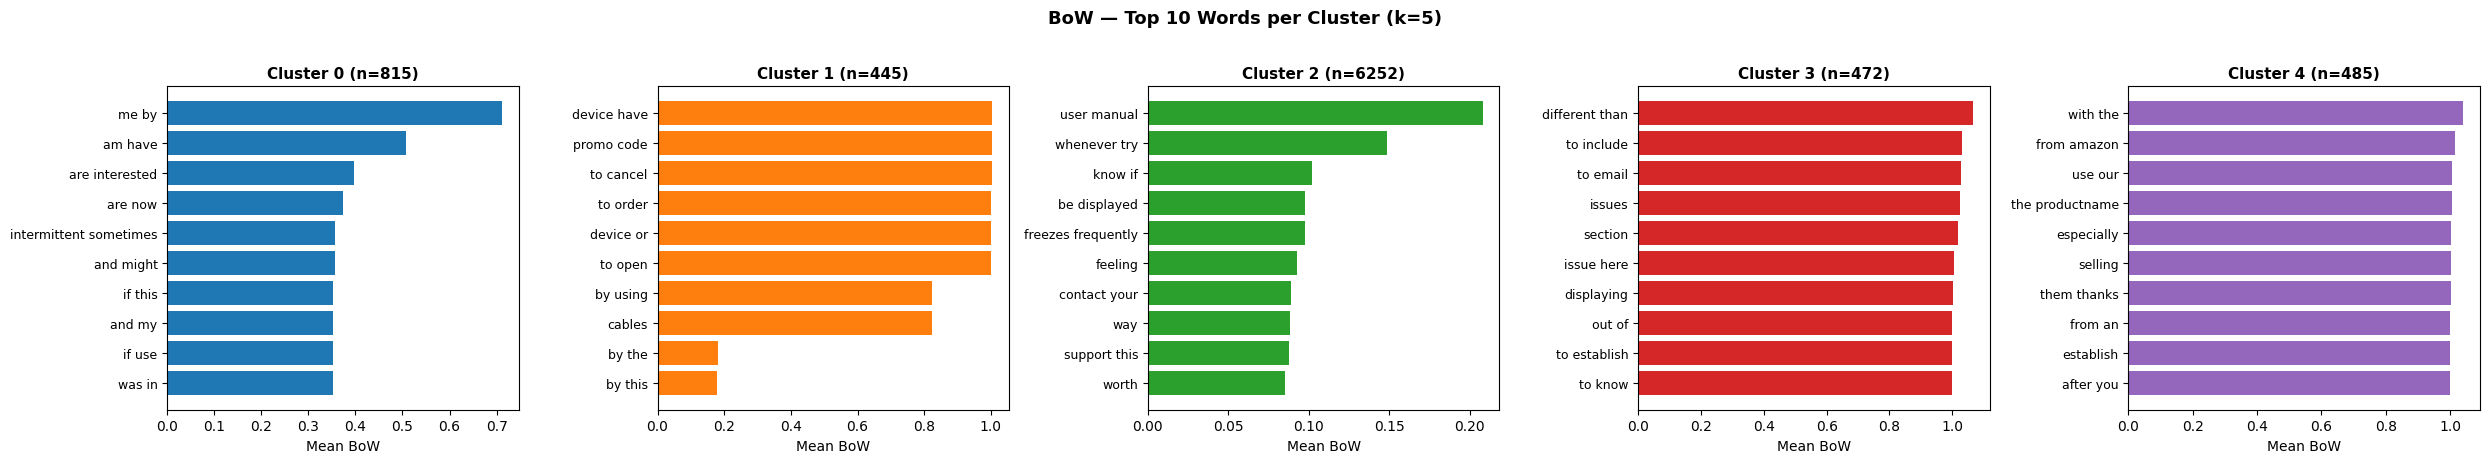

In [19]:
# BoW 
vectorize_boa(text_list = cleaned_text_df["cleaned_description"].to_list())
plot_cluster_top_words(X = X_bow.toarray(), 
                       cluster_labels = km_bow_labels, 
                       vectorizer = bow_vectorizer, 
                       n_top=10, 
                       save_path=os.path.join(figures_dir, 'clustering_bow_topwords.png'),
                       title_prefix="BoW"
                       )

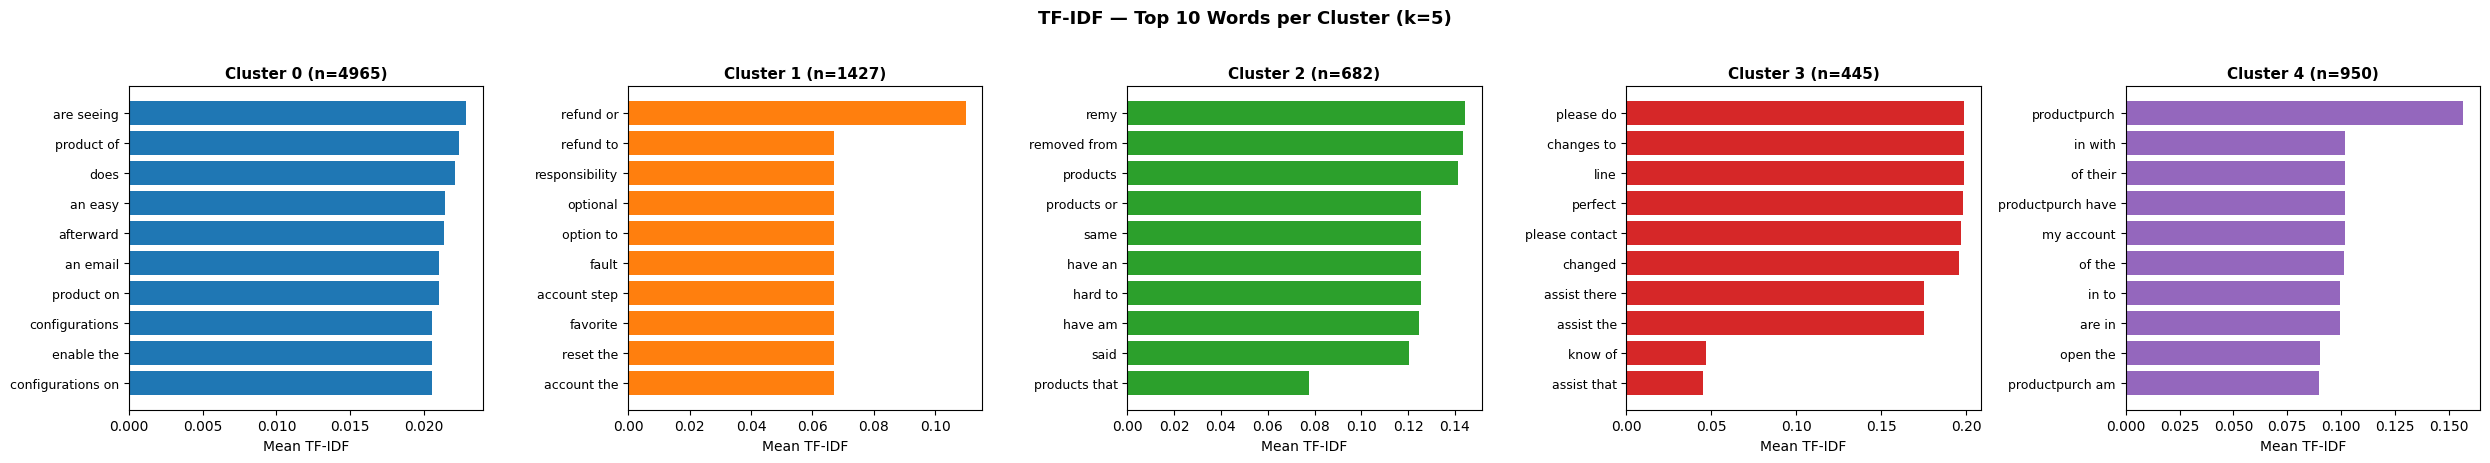

In [20]:
# TF-IDF
vectorize_tfidf(text_list = cleaned_text_df["cleaned_description"].to_list())
plot_cluster_top_words(X = X_tfidf.toarray(), 
                       cluster_labels = km_tfidf_labels, 
                       vectorizer = tfidf_vectorizer, 
                       n_top=10, 
                       save_path=os.path.join(figures_dir, 'clustering_tfidf_topwords.png'),
                       title_prefix="TF-IDF")

#### BoW, TF-IDF, Skipgram and SBERT heatmap for the clusters count and proportions 

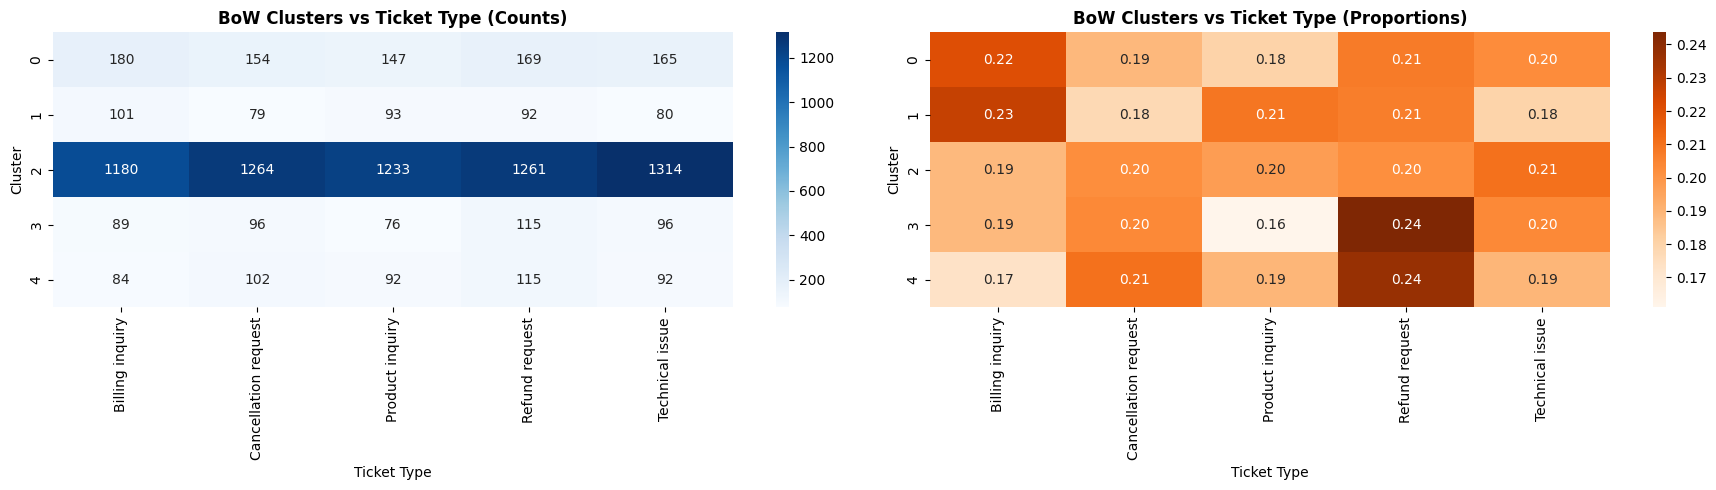

In [21]:
# BoW 
plot_cluster_heatmaps(
    cluster_labels = km_bow_labels, 
    df = df, 
    title_prefix="BoW",
    save_path=os.path.join(figures_dir, 'clustering_bow_heatmaps.png')
)

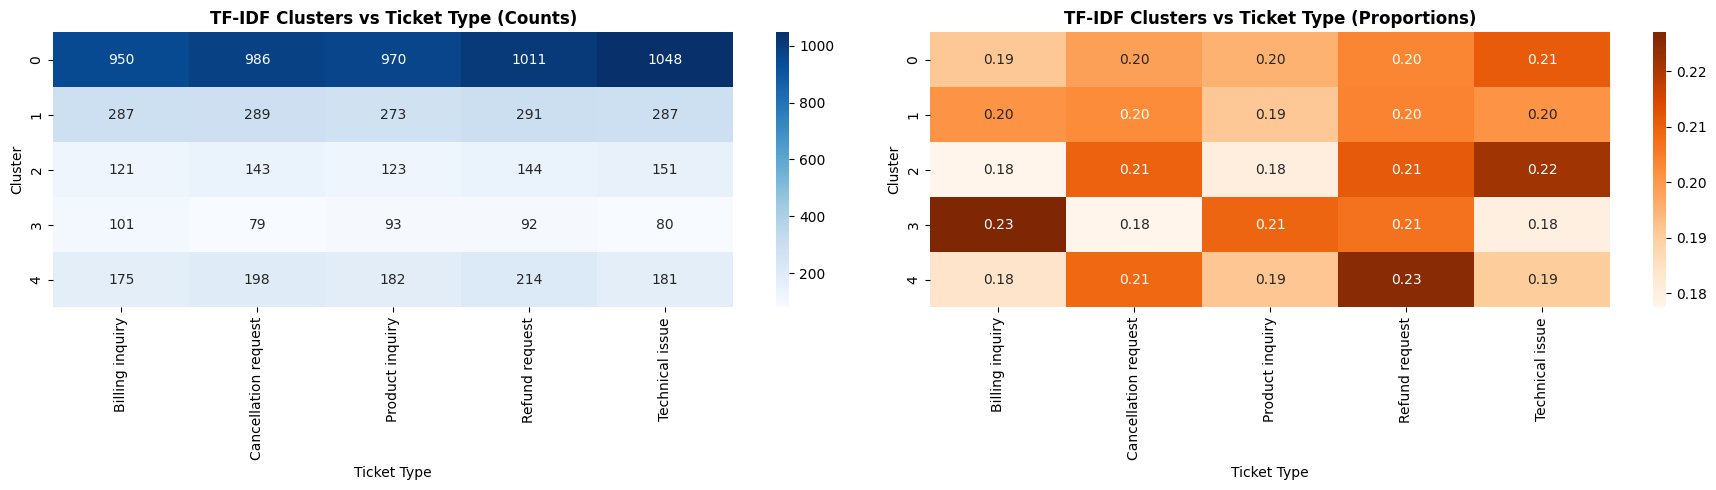

In [22]:
# TF-IDF 
plot_cluster_heatmaps(
    cluster_labels = km_tfidf_labels, 
    df = df, 
    title_prefix="TF-IDF",
    save_path=os.path.join(figures_dir, 'clustering_tfidf_heatmaps.png')
)

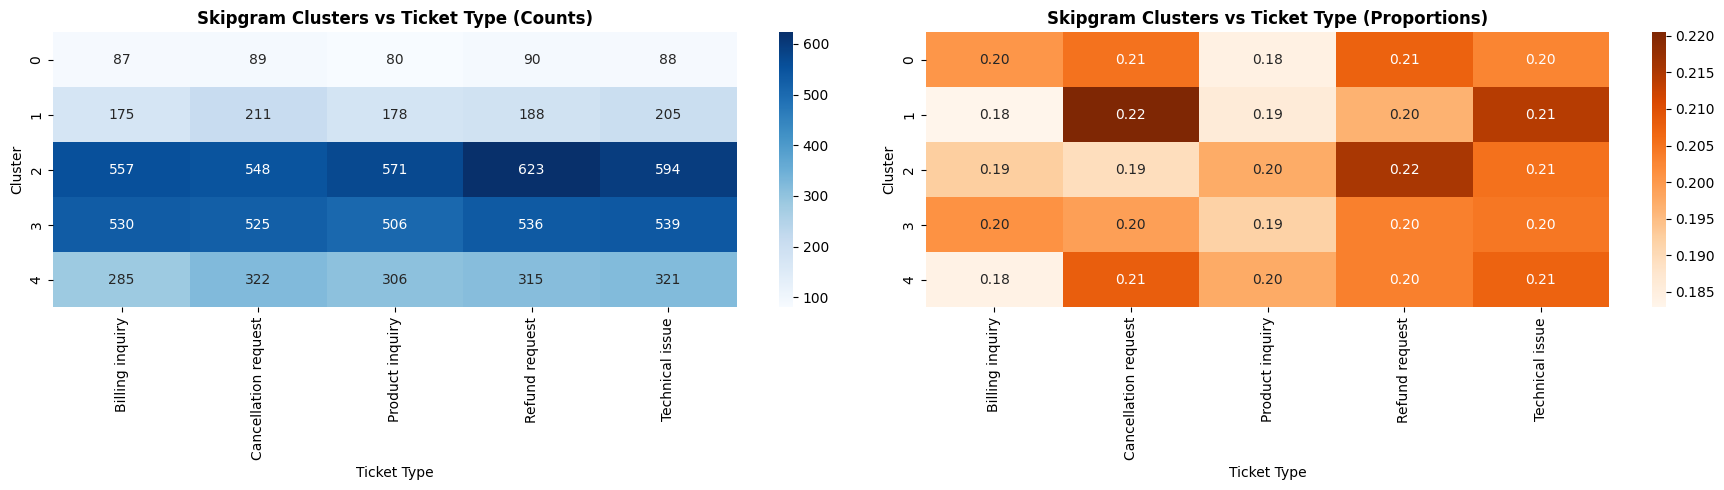

In [23]:
# Skipgram
plot_cluster_heatmaps(
    cluster_labels = km_skipgram_labels, 
    df = df, 
    title_prefix="Skipgram",
    save_path=os.path.join(figures_dir, 'clustering_skipgram_heatmaps.png')
)

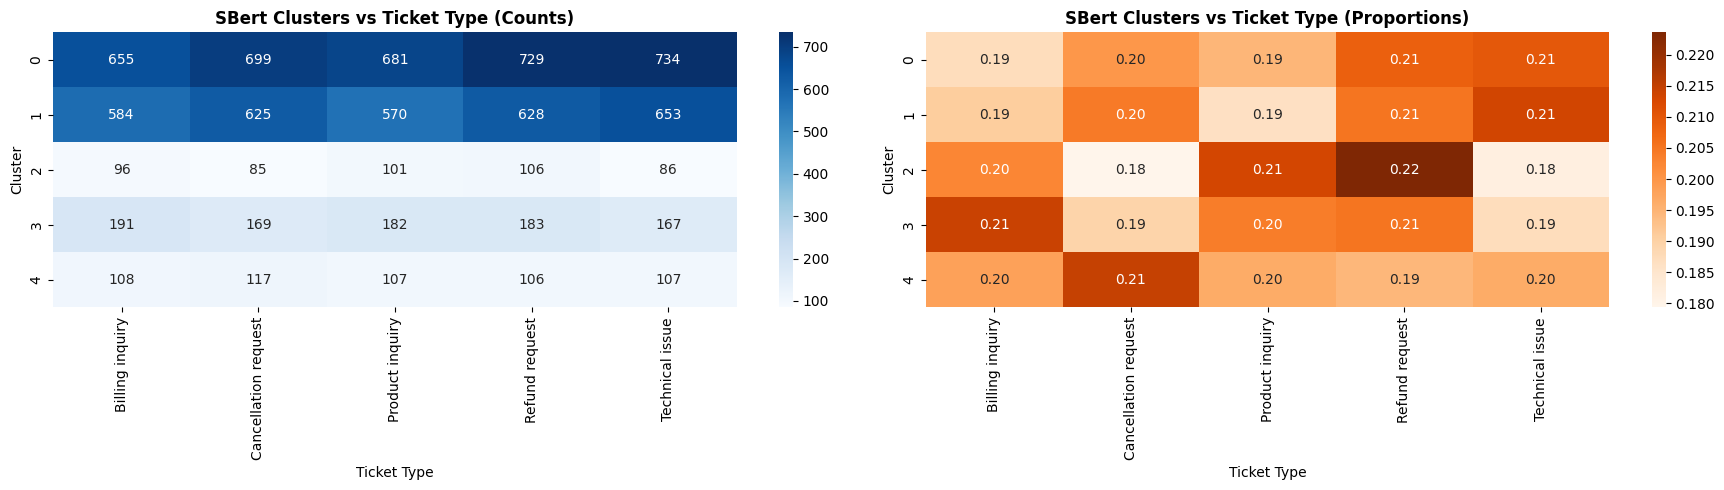

In [24]:
# Sbert
plot_cluster_heatmaps(
    cluster_labels = km_sbert_labels, 
    df = df, 
    title_prefix="SBert",
    save_path=os.path.join(figures_dir, 'clustering_sbert_heatmaps.png')
)

#### BoW, TF-IDF, Skipgram and SBERT - Compare the cluster sizes  

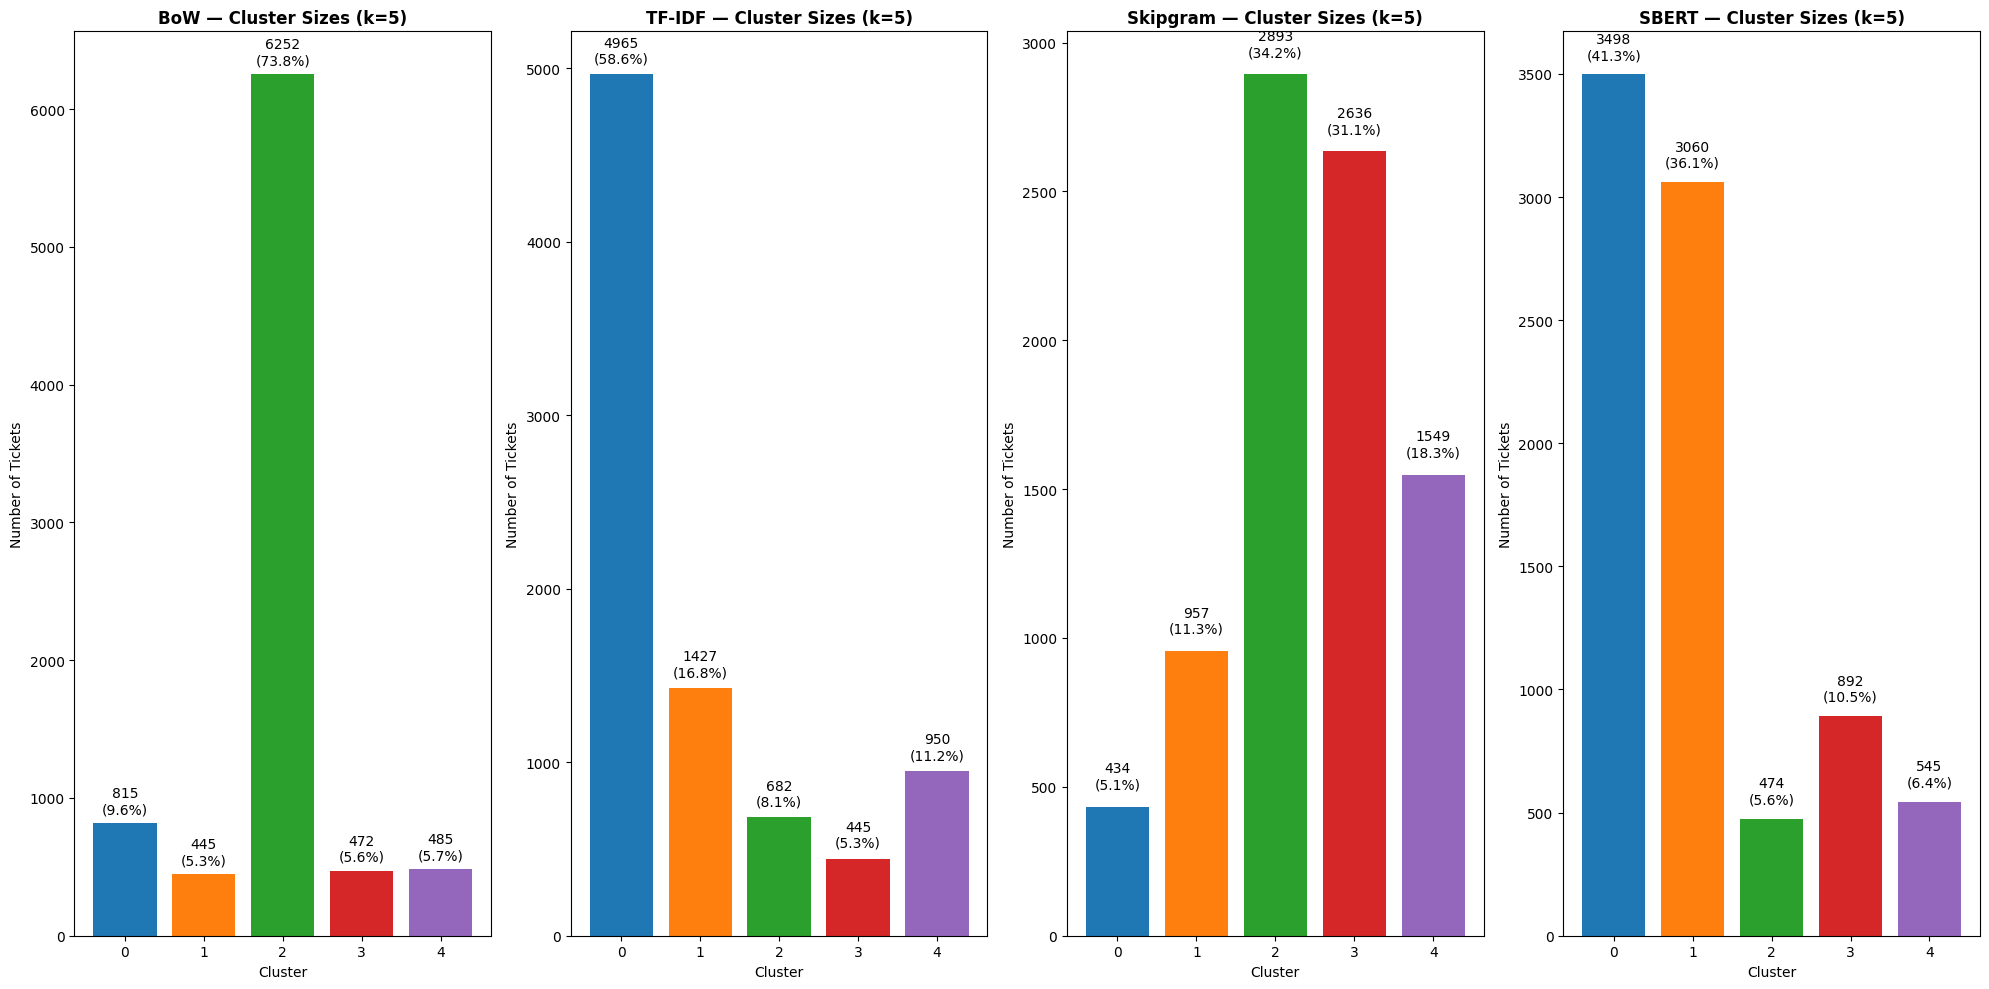

In [25]:
plot_cluster_size([(km_bow_labels, "BoW"),
                   (km_tfidf_labels, "TF-IDF"),
                   (km_skipgram_labels, "Skipgram"), 
                   (km_sbert_labels, "SBERT")],
                   save_path=os.path.join(figures_dir, 'clustering_cluster_sizes_comparison.png')
                   )

## CLUSTER STABILITY

#### CLUSTER STABILITY ACCROSS K-VALUES ON KMEAN

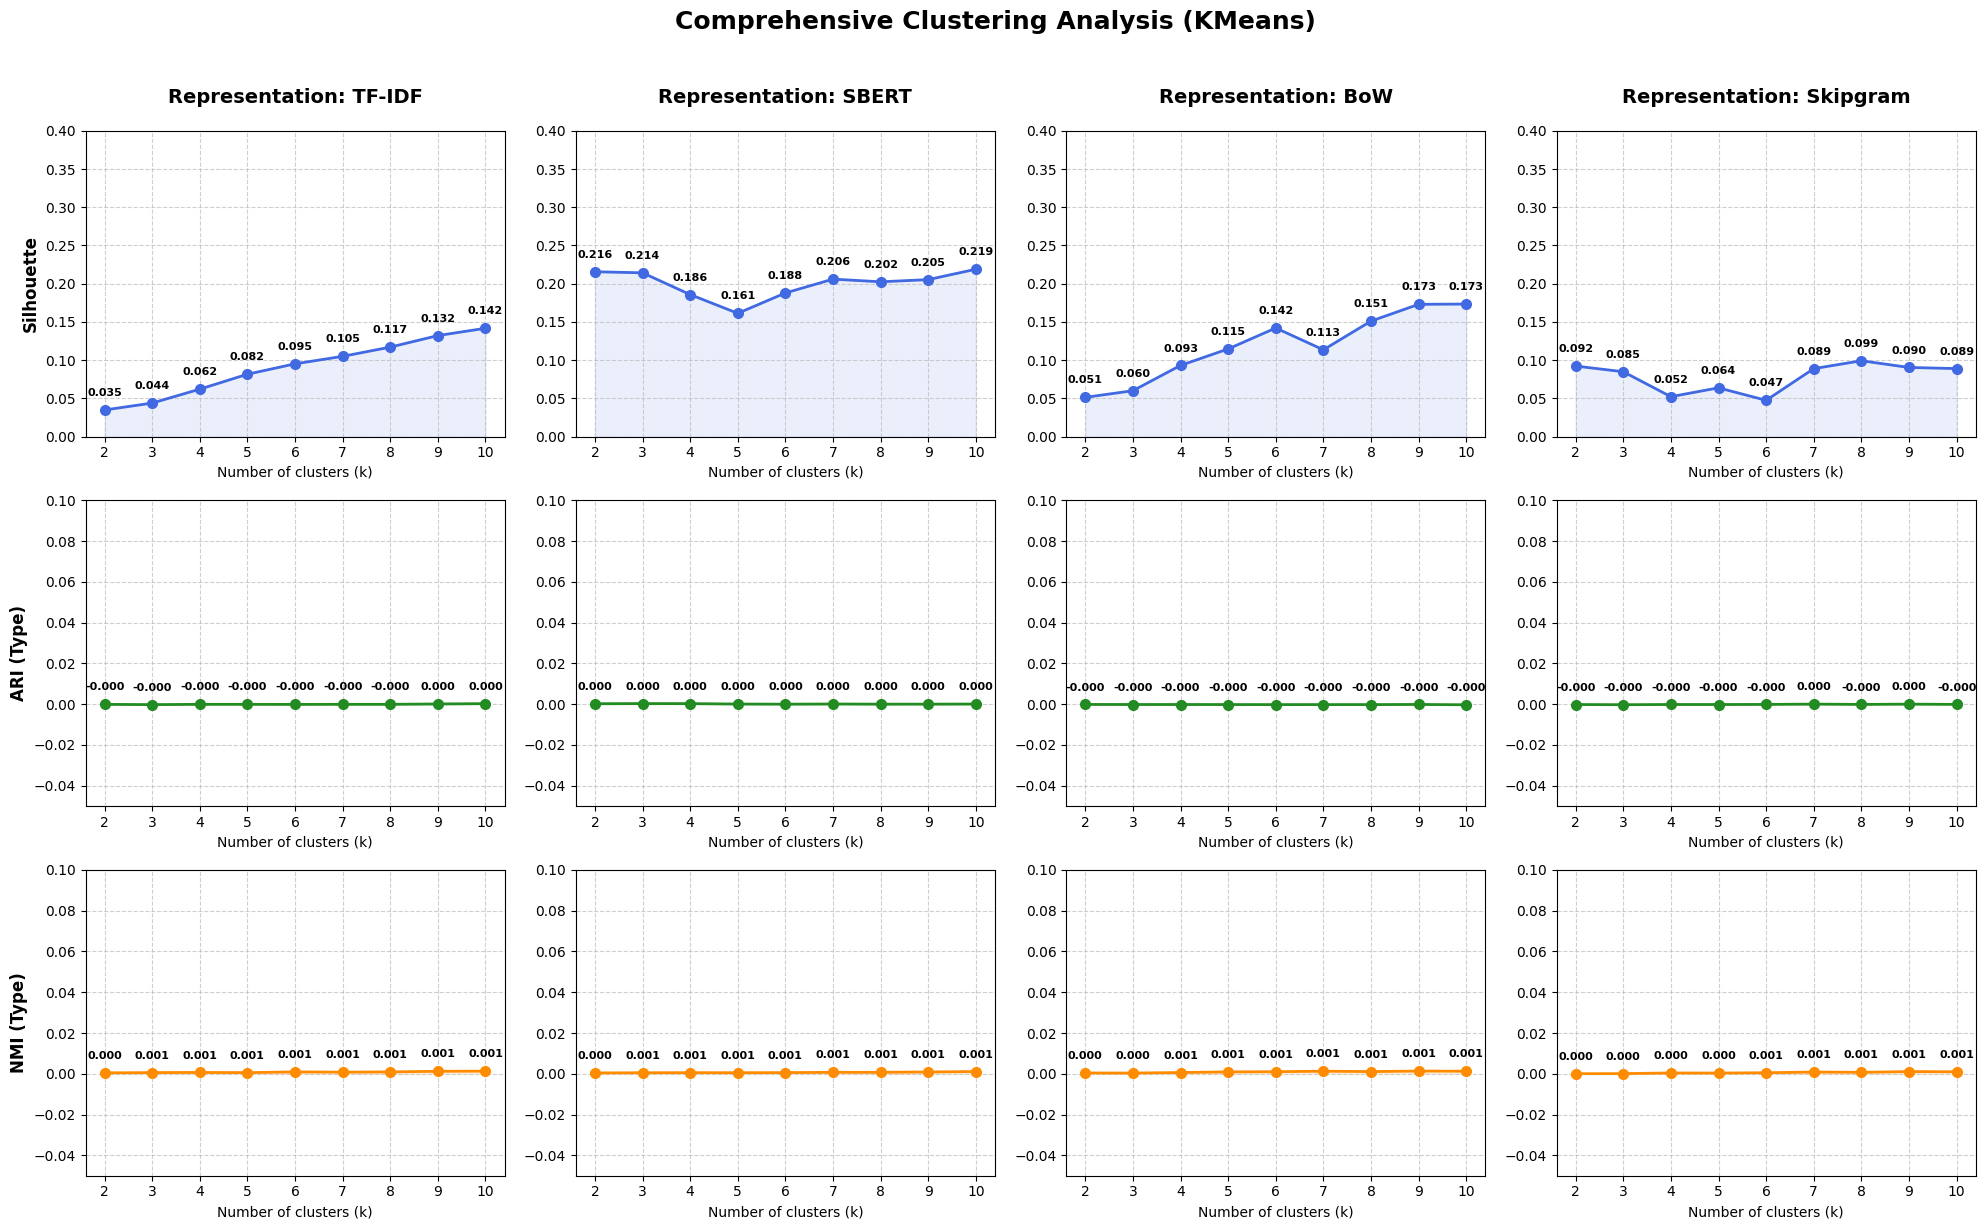

In [26]:
visualize_cluster_stability(
    df=all_results, 
    algorithm='KMeans',
    save_path=os.path.join(figures_dir, 'clustering_kmeans_stability.png')
)

In [ ]:
# Create a save directory for clustering.
clustering_models_dir = os.path.join(root_path, 'models', 'clustering')
os.makedirs(clustering_models_dir, exist_ok=True)

# Pack the various labels obtained in cluster analysis into a dictionary
clustering_labels = {
    'km_tfidf_labels': km_tfidf_labels,
    'km_sbert_labels': km_sbert_labels,
    'X_tfidf': X_tfidf,
    'X_sbert': X_sbert
}
save_path = os.path.join(clustering_models_dir, 'clustering_labels.pkl')
with open(save_path, 'wb') as f:
    pickle.dump(clustering_labels, f)

print(f"Clustering tags have been successfully saved to: {save_path}")

Clustering tags have been successfully saved to: E:\Study\Bristol\IATA\Group_Project\Code\EMATM0067_2025_TB-2-g43-ThiruvelAP\models\clustering\clustering_labels.pkl


# CONCLUSIONS OF CLUSTERING ANALYSIS ON TICKET CORPUS

## TEXT REPRESENTATION COMPARISON: SILHOUETTE ANALYSIS

### SBERT Embeddings
- KMeans silhouette scores range from **0.169 to 0.222**, peaking at
  k=3 (0.216) and k=10 (0.222). This is the highest across all representations.
- HAC scores are remarkably stable across all k values, ranging from
  **0.208 to 0.252**, peaking at k=10 (0.252) the highest single score
  across ALL methods and algorithms tested.
- The early KMeans peak at k=3 suggests approximately 2â€“3 natural semantic
  groupings exist in the embedding space, while the HAC peak at k=10
  indicates finer-grained hierarchical sub-clusters exist within the data.
- SBERT produces consistent results across preprocessing variants,
  confirming that sentence-level semantics are captured from natural
  sentence structure rather than individual token frequencies.

### Bag-of-Words
- KMeans silhouette scores range from **0.050 to 0.181**, increasing
  monotonically with k no clear elbow or peak visible.
- Silhouette generally increases with k, suggesting the algorithm finds
  smaller, tighter micro-clusters in the sparse high-dimensional space
  rather than broad thematic groupings.
- HAC scores range from **0.050 to 0.147**, also increasing monotonically,
  but consistently below KMeans at the same k.
- The cluster size distribution at k=5 reveals severe imbalance one
  dominant cluster contains **6,252 tickets (73.8%)** while the remaining
  four clusters share only 2,217 tickets. This confirms that BoW collapses
  most tickets into a single dense region dominated by shared template vocabulary.

### TF-IDF
- KMeans silhouette scores range from **0.035 to 0.143**, the lowest
  across all representations.
- This is initially surprising since TF-IDF is designed to upweight
  discriminative terms. However, in this corpus the discriminative terms
  that survive TF-IDF weighting carry very little semantic signal what
  remains after downweighting dominant template vocabulary are low-frequency
  incidental fragments rather than issue-specific language.
- HAC scores range from **0.021 to 0.095**, the lowest of all algorithm
  and representation combinations.
- At k=5, one dominant cluster contains **4,965 tickets (58.6%)**, confirming
  that TF-IDF weighting still fails to separate ticket categories in this
  template-dominated corpus.

### Skip-gram
- KMeans silhouette scores range from **0.045 to 0.107**, showing the most
  unstable pattern â€” starting at 0.091 at k=2, dropping to 0.045 at k=4,
  then gradually recovering toward k=10 (0.107).
- HAC scores range from **0.020 to 0.065**, similarly unstable with a sharp
  dip at k=6 (0.020) before recovering.
- At k=5, Skip-gram produces the most balanced cluster distribution among
  frequency-based methods two dominant clusters of **2,893 (34.2%)** and
  **2,636 (31.1%)** with three smaller groups, partially mirroring SBERT's
  structure but at lower silhouette scores.
- The instability pattern suggests word-level averaged embeddings capture
  some genuine structure but with less consistency than sentence-level
  representations, likely due to loss of positional context during averaging
  and domain mismatch between the pretrained Google News corpus and
  support ticket vocabulary.

### KEY FINDING
- Semantic embeddings (SBERT) capture substantially more cluster-relevant
  structure than frequency-based representations (BoW, TF-IDF) and
  word-level embeddings (Skip-gram) in this corpus.
- This suggests the discriminative signal between ticket categories lies
  in sentence-level meaning rather than individual word frequencies
  consistent with a templated corpus where word distributions are nearly
  identical across categories.

## ALGORITHM COMPARISON: KMeans vs HAC

- KMeans generally outperforms HAC at lower k values across all representations.
- For SBERT at k=3, KMeans achieves **0.216** compared to HAC's pattern
  of stable scores around 0.220.
- However, HAC reaches its peak of **0.252** at k=10 on SBERT the
  highest single score across ALL methods and algorithms suggesting
  HAC finds better hierarchical structure at fine granularity for
  semantic embeddings.
- For BoW and TF-IDF, KMeans consistently outperforms HAC at all k values,
  suggesting centroid-based partitioning is better suited to sparse
  frequency vectors.
- This pattern suggests KMeans is better at finding broad, balanced
  partitions at lower k, while HAC can discover more nuanced hierarchical
  structure at finer granularity particularly for dense semantic embeddings.

### KEY FINDINGS
- Centroid-based methods (KMeans) are the most robust choice for
  frequency-based representations.
- HAC on SBERT achieves the best overall silhouette score (0.252 at k=10),
  making it the optimal configuration for this corpus.
- DBSCAN is unsuitable for sparse text vectors but partially viable on
  dense embeddings.


## CLUSTER ALIGNMENT WITH KNOWN LABELS (ARI / NMI)

This is the most significant finding of the analysis.

Across ALL configurations tested â€” every combination of representation
(BoW, TF-IDF, SBERT, Skip-gram), algorithm (KMeans, HAC), k value (2â€“10):

- **ARI ranges from -0.000 to +0.000**
- **NMI ranges from 0.000 to 0.001**

These values indicate NO systematic correspondence between the clusters
discovered from text content and the existing Ticket Type label categories.
This result is consistent across all representations and k values it is
not an artefact of any single method.

### Interpretation
The Ticket Type labels assigned to each ticket are not distinguishable
from the textual content of the ticket descriptions. This is directly
explained by three EDA findings:

1. **Template homogeneity:** 100% of tickets share the same structural
   template, making language patterns nearly identical across categories.

2. **Uniform vocabulary distribution:** N-gram analysis shows the same
   top unigrams, bigrams, and trigrams appear across all Ticket Types
   with similar frequencies no category has distinctive vocabulary.

3. **Balanced metadata:** Cross-tabulation heatmaps confirm that Ticket
   Priority, Channel, and Product are evenly distributed across all
   Ticket Types â€” no category has distinctive contextual markers.

This does NOT mean the clustering is failing. Silhouette scores above
0.20 (SBERT) confirm that clusters with internal coherence exist they
simply capture a different structure than the pre-assigned labels.
The near-zero ARI and NMI instead suggest that Ticket Type labels were
assigned based on metadata or customer-selected categories rather than
the language used in the descriptions themselves.


## STABILITY ANALYSIS

### BoW and TF-IDF
- Silhouette scores increase approximately monotonically with k for
  both KMeans and HAC.
- No clear elbow or peak is visible, suggesting no natural cluster count
  exists in these representations the algorithm simply finds tighter
  groupings as k increases.
- This monotonic increase is characteristic of data without well-separated
  clusters, where increasing k always reduces intra-cluster variance
  mechanically.

### SBERT
- Shows the most informative pattern: KMeans peaks at k=3 (0.216),
  dips at k=5 (0.169), then gradually recovers toward k=10 (0.222).
- HAC maintains a remarkably stable range (0.208â€“0.252) across all k,
  suggesting the hierarchical structure is robust to the choice of k.
- The KMeans dip-then-recovery pattern indicates that k=4â€“5 splits a
  natural cluster, degrading coherence, but by k=9â€“10 the algorithm
  finds enough fine-grained structure to compensate.
- This non-monotonic KMeans pattern is evidence of genuine structure
  unlike BoW and TF-IDF where higher k always helps mechanically.

### Skip-gram
- Shows the most unstable pattern dropping sharply at k=4 (0.045)
  then gradually recovering, with HAC showing a severe dip at k=6 (0.020).
- This instability suggests word-level averaging produces inconsistent
  cluster boundaries that are highly sensitive to k, unlike SBERT which
  captures sentence-level structure more robustly.

## CONCLUSIONS

The clustering analysis reveals four key findings:

**1. SEMANTIC REPRESENTATIONS OUTPERFORM FREQUENCY-BASED METHODS**
SBERT embeddings consistently achieve the highest silhouette scores
(KMeans: 0.169â€“0.222, HAC: 0.208â€“0.252) compared to BoW (0.050â€“0.181),
Skip-gram (0.045â€“0.107) and TF-IDF (0.035â€“0.143), confirming that
sentence-level semantic similarity captures more cluster-relevant
structure in customer support text than word-level frequency patterns.

**2. TEXT CONTENT DOES NOT SEPARATE BY EXISTING LABELS**
Near-zero ARI (â‰ˆ0.000) and NMI (â‰ˆ0.001) across all configurations
demonstrate that Ticket Type categories cannot be recovered from ticket
description text alone. This is a direct consequence of template-driven
language homogeneity identified in the EDA, where identical vocabulary
distributions across categories make textual discrimination impossible.

**3. CLUSTERS EXIST BUT CAPTURE DIFFERENT STRUCTURE**
Silhouette scores above 0.20 for SBERT confirm that meaningful groupings
exist in the data they correspond to something other than pre-assigned
metadata labels. The balanced cluster size distribution of SBERT at k=5
(two groups of ~40% and ~36%) further suggests genuine latent structure
rather than artificial partitioning.

**4. HAC ON SBERT IS THE OPTIMAL CONFIGURATION**
HAC achieves the highest overall silhouette score of 0.252 at k=10 on
SBERT embeddings outperforming all KMeans configurations. This suggests
hierarchical clustering better captures the nested structure of semantic
similarity in customer support text, while KMeans remains the more robust
choice for frequency-based representations.